Saving final_query_campaigns.csv to final_query_campaigns.csv
--- Loading Data ---

--- Training Time-Series Model ---
Time Trend Coefficient: -5.52 (How much revenue naturally changes per day)


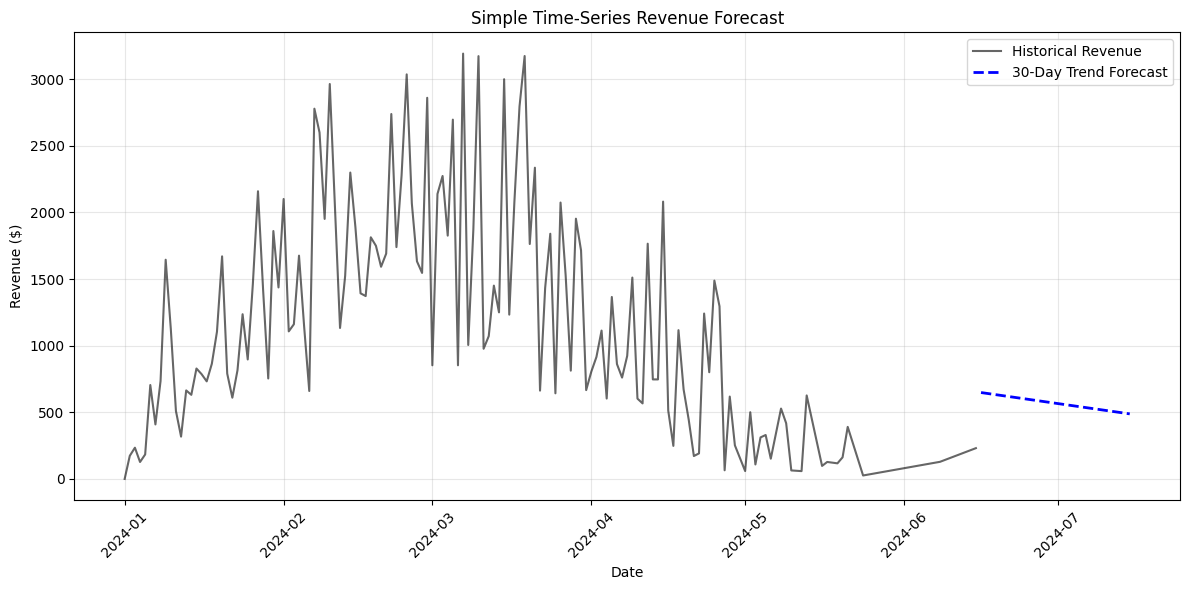


--- 30-Day Forecast Summary ---
Total Projected Revenue: $17,041.75
Average Projected Daily: $568.06

--- Preparing Final Export ---
Success! Data exported to time_series_revenue_forecast.csv.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from google.colab import files

# ==========================================
# LOAD AND AGGREGATE
# ==========================================
uploaded = files.upload()
print("--- Loading Data ---")
df = pd.read_csv("final_query_campaigns.csv")
df['date'] = pd.to_datetime(df['date'])

daily_df = df.groupby('date').agg({
    'daily_spend': 'sum',
    'total_time_decay_revenue': 'sum'
}).reset_index().sort_values('date')

daily_df['days'] = (daily_df['date'] - daily_df['date'].min()).dt.days



# ==========================================
# TIME-SERIES MODELING
# ==========================================
print("\n--- Training Time-Series Model ---")
# We only use 'days' (Time) as the predictor.
X = daily_df[['days']]
y = daily_df['total_time_decay_revenue']

model = LinearRegression()
model.fit(X, y)

print(f"Time Trend Coefficient: {model.coef_[0]:.2f} (How much revenue naturally changes per day)")

# ==========================================
# 30-DAY FORECAST
# ==========================================
future_days = 30
last_day = daily_df['days'].max()
last_date = daily_df['date'].max()

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)
future_df = pd.DataFrame({
    'date': future_dates,
    'days': np.arange(last_day + 1, last_day + 1 + future_days)
})

# Predict using only the 'days' feature. Clamp at 0 to prevent negative revenue.
future_df['pred_revenue'] = np.maximum(0, model.predict(future_df[['days']]))

# ==========================================
# VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

# Historical Data
plt.plot(daily_df['date'], y, label='Historical Revenue', color='black', alpha=0.6)

# Forecast
plt.plot(future_df['date'], future_df['pred_revenue'], linestyle='--', color='blue', linewidth=2, label='30-Day Trend Forecast')

plt.title("Simple Time-Series Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# ==========================================
# OUTPUT SUMMARY
# ==========================================
print("\n--- 30-Day Forecast Summary ---")
print(f"Total Projected Revenue: ${future_df['pred_revenue'].sum():,.2f}")
print(f"Average Projected Daily: ${future_df['pred_revenue'].mean():,.2f}")

# ==========================================
# 7. EXPORT FOR DASHBOARDING
# ==========================================
print("\n--- Preparing Final Export ---")

# Standardize column names for clean BI reporting
hist_export = daily_df[['date', 'total_time_decay_revenue']].rename(
    columns={'total_time_decay_revenue': 'Revenue'}
)
hist_export['Type'] = 'Historical'

future_export = future_df[['date', 'pred_revenue']].rename(
    columns={'pred_revenue': 'Revenue'}
)
future_export['Type'] = 'Forecast'

# Combine into one master table
final_dashboard_data = pd.concat([hist_export, future_export], ignore_index=True)

# Export and Download
filename = "time_series_revenue_forecast.csv"
final_dashboard_data.to_csv(filename, index=False)
print(f"Success! Data exported to {filename}.")
files.download(filename)